# DSC 180A Paper Replication
### Microbial Diversity in Clinical Microbiome Studies: Sample Size and Statistical Power Considerations
## Setup

In [1]:
import sys
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled

print(sys.executable) 

env_root = sys.prefix

env_bin = os.path.join(env_root, "bin")
os.environ["PATH"] = env_bin + os.pathsep + os.environ.get("PATH", "")

env_r_lib = os.path.join(env_root, "lib", "R", "library")
ro.r(f'.libPaths("{env_r_lib}")')

print("R libPaths now:")
print(ro.r(".libPaths()"))
print("phyloseq installed?", isinstalled("phyloseq"))

/home/k5zhao/.conda/envs/qiime2-amplicon-2025.7/bin/python
R libPaths now:
[1] "/home/k5zhao/.conda/envs/qiime2-amplicon-2025.7/lib/R/library"
[2] "/opt/conda/lib/R/library"                                     

phyloseq installed? True


## Imports

In [27]:
import pandas as pd
import numpy as np
import qiime2 as q2
import seaborn as sns
import matplotlib.pyplot as plt
import re

from statsmodels.stats.power import tt_ind_solve_power
from statistics import mean, stdev
from skbio import DistanceMatrix
from qiime2.plugins import fragment_insertion, diversity, emperor
from qiime2 import Metadata, Artifact
from qiime2.plugins.feature_table.methods import rarefy
from qiime2.plugins.phylogeny.methods import midpoint_root
from skbio import TreeNode
from skbio.diversity.alpha import faith_pd
from q2_types.tree import NewickFormat

import rpy2.robjects as ro
from rpy2.robjects.packages import isinstalled

import skbio

import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

import shap
from biom import load_table

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline

## Data Preprocessing

### Load Original Feature Table

In [14]:
ft = Artifact.load('../qiita_artifacts/feature_table.qza')
ft_df = ft.view(pd.DataFrame)
ft_df.head()

,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCGAAGCAAGTCTGAAGTGAAAACCCAGGGCTCAACC,ACGTAGGGGGCTAGCGTTATCCGGATTTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTTAAGTCAGGAGTGAAAGGCTACGGCTCAACC,ACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTCAACC,ACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCGCGCAGGCGGATAGGTCAGTCTGTCTTAAAAGTTCGGGGCTTAACC,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGACGGGCAAGTCTGAAGTGAAAGGCAGGGGCTCAACC,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGAAGAGCAAGTCTGATGTGAAAGGCTGGGGCTTAACC,ACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGATAGGTCAGTCTGTCTTAAAAGTTCGGGGCTTAACC,ACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACG,ACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTTAACC,ACGTATGTCACGAGCGTTATCCGGATTTATTGGGCGTAAAGCGCGTCTAGGTGGTTATGTAAGTCTGATGTGAAAATGCAGGGCTCAACT,...,ACGTAGGGAGCGAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGTAGGCGGGTCAGCAAGTCCGTTGTTAAATCTACCGGCTCAACC,ATGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGAGTAGGCGGGATTACAAGTCTGATGTGAAATACCGAGGCTTAACT,ACATAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGCGTGCAGCCGGGCCGGCAAGTCAGATGTGAAATCTGGAGGCTTAACC,ATGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGTGCGTAGGCGGCGGATTAAGTCCGGAGTAAAATTGTGGGGCTCAACC,ACATAGGGGGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGTGCGTAGGCGGCATCGTAAGTCTGTTGTGAAAGGCGATGGCTTAACC,ACGTAGGTGGCAAGCGTTGTCCGGAATTACTGGGCGTAAAGGGCGCGTAGGCGGTAGATCAAGTCGCATGTGAAATACCCGGGCTCAACC,ATGTAGGGGGCGAGCGTTATCCGGAATCATTGGGCGTAAAGAGCGCGTAGGCGGCCCCTCAAGCGGGATCTCTAATCCGAGGGCTCAACC,AGGTAGGGGGCAAGCGTTATCCGGAATTACTGGGTGTAAAGGGTGAGTAGGCGGCACGGCAAGTAAGATGTGAAAGCCCACGGCTTAACT,ACGGAAGGTCCGGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTATGCCGTCTTCTGCTTGAAAAAAGAAAATTTGCGGCTCAACC,ACCTAGGTCCCGAGCGTTATCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTAGATAAGTCTGAAGTTAAAGGCTGTGGCTTAACC
1629.SubjectIBD026,46430.0,18924.0,6645.0,5276.0,4450.0,2324.0,1322.0,1279.0,1043.0,915.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1629.SubjectIBD414,0.0,41.0,0.0,82.0,0.0,0.0,0.0,1429.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1629.SubjectIBD244,1551.0,1089.0,0.0,3248.0,0.0,4385.0,0.0,15048.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1629.SubjectIBD676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1629.SubjectIBD198,0.0,8573.0,0.0,21.0,0.0,0.0,0.0,271.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Rarefy Table

In [15]:
rarefied = rarefy(table=ft, sampling_depth=10000).rarefied_table
rarefied.save('../out/rarefied_table.qza')

'../out/rarefied_table.qza'

In [67]:
# alternatively, load the existing rarefied table for consistent results instead of resampling
# rarefied = Artifact.load('../out/rarefied_table.qza')

In [16]:
rarefied_df = rarefied.view(pd.DataFrame)
rarefied_df.sum(axis=1)

1629.SubjectIBD026    10000.0
1629.SubjectIBD414    10000.0
1629.SubjectIBD244    10000.0
1629.SubjectIBD198    10000.0
1629.SubjectIBD391    10000.0
                       ...   
1629.SubjectIBD222    10000.0
1629.SubjectIBD195    10000.0
1629.SubjectIBD472    10000.0
1629.SubjectIBD040    10000.0
1629.SubjectIBD249    10000.0
Length: 611, dtype: float64

### Import and Format Insertion Tree

In [17]:
nwk = NewickFormat('../qiita_artifacts/insertion_tree.relabelled.tre', mode='r')
tree_qza = Artifact.import_data('Phylogeny[Rooted]', nwk)
tree_qza.save('../out/insertion_tree.qza')

'../out/insertion_tree.qza'

### Alpha Diversity Calculations

In [55]:
insertion_tree = q2.Artifact.load('../out/insertion_tree.qza')

faith_res = diversity.actions.alpha_phylogenetic(
    table=rarefied,
    phylogeny=insertion_tree,
    metric='faith_pd'
)

faith_pd = faith_res.alpha_diversity.view(pd.Series)
faith_pd

Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

faithpd -i /tmp/qiime2/mwdai/processes/57084-1764462429.98@mwdai/tmp/q2-OutPath-xpllroi5 -t /tmp/qiime2/mwdai/data/4ba07238-a214-4c3b-8d3d-c9dbc566693a/data/tree.nwk -o /tmp/qiime2/mwdai/processes/57084-1764462429.98@mwdai/tmp/q2-OutPath-fcw4br5q



1629.SubjectIBD026     9.982057
1629.SubjectIBD414    11.883945
1629.SubjectIBD244    12.799128
1629.SubjectIBD198    14.988233
1629.SubjectIBD391    22.113480
                        ...    
1629.SubjectIBD222    13.676959
1629.SubjectIBD195    26.969802
1629.SubjectIBD472    15.680575
1629.SubjectIBD040    21.763128
1629.SubjectIBD249     5.972395
Name: faith_pd, Length: 611, dtype: float64

### Beta Diversity Calculations

In [56]:
unifrac_res = diversity.actions.beta_phylogenetic(
    table=rarefied,
    phylogeny=insertion_tree,
    metric='unweighted_unifrac'
)
unifrac_dm = unifrac_res.distance_matrix.view(DistanceMatrix)
unifrac_df = pd.DataFrame(unifrac_dm.data, index=unifrac_dm.ids, columns=unifrac_dm.ids)
unifrac_df

Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

ssu -i /tmp/qiime2/mwdai/data/09e83a88-a6de-4211-8c9d-a8880b7ba515/data/feature-table.biom -t /tmp/qiime2/mwdai/data/4ba07238-a214-4c3b-8d3d-c9dbc566693a/data/tree.nwk -m unweighted -o /tmp/qiime2/mwdai/processes/57084-1764462429.98@mwdai/tmp/q2-OutPath-rfk2nuva



,1629.SubjectIBD026,1629.SubjectIBD414,1629.SubjectIBD244,1629.SubjectIBD198,1629.SubjectIBD391,1629.SubjectIBD105,1629.SubjectIBD537,1629.SubjectIBD489,1629.SubjectIBD367,1629.SubjectIBD069,...,1629.SubjectIBD108,1629.SubjectIBD551,1629.SubjectIBD163,1629.SubjectIBD484,1629.SubjectIBD419,1629.SubjectIBD222,1629.SubjectIBD195,1629.SubjectIBD472,1629.SubjectIBD040,1629.SubjectIBD249
1629.SubjectIBD026,0.000000,0.590499,0.644049,0.626872,0.717035,0.657996,0.625844,0.650216,0.580965,0.597716,...,0.571201,0.503795,0.593997,0.670897,0.668671,0.661312,0.727095,0.632755,0.686421,0.633057
1629.SubjectIBD414,0.590499,0.000000,0.620351,0.541259,0.640230,0.543441,0.573555,0.498044,0.481049,0.475367,...,0.554090,0.624024,0.630631,0.579499,0.487340,0.581641,0.665573,0.490401,0.593943,0.672322
1629.SubjectIBD244,0.644049,0.620351,0.000000,0.644992,0.655637,0.586390,0.646073,0.589843,0.661471,0.627031,...,0.643000,0.662956,0.589469,0.702784,0.606742,0.703783,0.733366,0.627313,0.658595,0.622177
1629.SubjectIBD198,0.626872,0.541259,0.644992,0.000000,0.622083,0.467797,0.551574,0.518603,0.592608,0.508979,...,0.603785,0.667544,0.665148,0.597241,0.542922,0.612473,0.566244,0.547129,0.541926,0.732609
1629.SubjectIBD391,0.717035,0.640230,0.655637,0.622083,0.000000,0.657043,0.561013,0.539634,0.742907,0.593758,...,0.656057,0.713128,0.742044,0.543791,0.555536,0.601861,0.577680,0.586673,0.546713,0.813633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629.SubjectIBD222,0.661312,0.581641,0.703783,0.612473,0.601861,0.624801,0.608312,0.600053,0.633735,0.568287,...,0.621496,0.628632,0.644935,0.624681,0.589084,0.000000,0.668186,0.563388,0.579335,0.735019
1629.SubjectIBD195,0.727095,0.665573,0.733366,0.566244,0.577680,0.674901,0.589090,0.570481,0.756782,0.620522,...,0.712227,0.695861,0.789648,0.568694,0.639586,0.668186,0.000000,0.633456,0.546239,0.808570
1629.SubjectIBD472,0.632755,0.490401,0.627313,0.547129,0.586673,0.554533,0.554838,0.547946,0.601559,0.442278,...,0.597965,0.677040,0.682163,0.591852,0.548311,0.563388,0.633456,0.000000,0.498137,0.705542
1629.SubjectIBD040,0.686421,0.593943,0.658595,0.541926,0.546713,0.608103,0.524588,0.502916,0.685936,0.517214,...,0.639307,0.687642,0.728049,0.561237,0.597068,0.579335,0.546239,0.498137,0.000000,0.743642


In [57]:
faith_res.alpha_diversity.save('../out/alpha_diversity.qza')
unifrac_res.distance_matrix.save('../out/distance_matrix.qza')

'../out/distance_matrix.qza'

### Import and Process Metadata

In [58]:
metadata_df = pd.read_csv('../qiita_artifacts/metadata.txt', 
                       sep='\t', dtype=str, index_col=0, engine='python')
print(metadata_df.shape)
metadata_df.head()

(683, 58)


,BarcodeSequence,LinkerPrimerSequence,center_name,experiment_design_description,instrument_model,library_construction_protocol,linker,pcr_primers,platform,run_center,...,study_id,timepoint,uc_extent,year_diagnosed,qiita_artifact_id,qiita_study_title,qiita_study_alias,qiita_owner,qiita_principal_investigator,Description
SampleID,,,,,,,,,,,,,,,,,,,,,
1629.SubjectIBD403,GTAGAGCT,GTGCCAGCMGCCGCGGTAA,LBNL,Jansson_Lamendella_Crohns,Illumina HiSeq 2000,Illumina V4 515F/806RBC,GT,FWD:GTGCCAGCMGCCGCGGTAA; REV:GGACTACHVGGGTWTCTAAT,Illumina,Yale Center for Genome Analysis,...,1629,3,Left sided (E2),2007,43623,Dynamics of the gut microbiome in Inflammatory...,Jansson_Lamendella_Crohns,Gail Ackermann,Janet Jansson,SubjectIBD403
1629.SubjectIBD062,AACCGTTC,GTGCCAGCMGCCGCGGTAA,LBNL,Jansson_Lamendella_Crohns,Illumina HiSeq 2000,Illumina V4 515F/806RBC,GT,FWD:GTGCCAGCMGCCGCGGTAA; REV:GGACTACHVGGGTWTCTAAT,Illumina,Yale Center for Genome Analysis,...,1629,1,not applicable,1972,43623,Dynamics of the gut microbiome in Inflammatory...,Jansson_Lamendella_Crohns,Gail Ackermann,Janet Jansson,SubjectIBD062
1629.SubjectIBD396,GCCTCCCT,GTGCCAGCMGCCGCGGTAA,LBNL,Jansson_Lamendella_Crohns,Illumina HiSeq 2000,Illumina V4 515F/806RBC,GT,FWD:GTGCCAGCMGCCGCGGTAA; REV:GGACTACHVGGGTWTCTAAT,Illumina,Yale Center for Genome Analysis,...,1629,5,not applicable,2007,43623,Dynamics of the gut microbiome in Inflammatory...,Jansson_Lamendella_Crohns,Gail Ackermann,Janet Jansson,SubjectIBD396
1629.SubjectIBD041,TGATGCTA,GTGCCAGCMGCCGCGGTAA,LBNL,Jansson_Lamendella_Crohns,Illumina HiSeq 2000,Illumina V4 515F/806RBC,GT,FWD:GTGCCAGCMGCCGCGGTAA; REV:GGACTACHVGGGTWTCTAAT,Illumina,Yale Center for Genome Analysis,...,1629,2,Extensive (E3),1979,43623,Dynamics of the gut microbiome in Inflammatory...,Jansson_Lamendella_Crohns,Gail Ackermann,Janet Jansson,SubjectIBD041
1629.SubjectIBD090,AAGACACA,GTGCCAGCMGCCGCGGTAA,LBNL,Jansson_Lamendella_Crohns,Illumina HiSeq 2000,Illumina V4 515F/806RBC,GT,FWD:GTGCCAGCMGCCGCGGTAA; REV:GGACTACHVGGGTWTCTAAT,Illumina,Yale Center for Genome Analysis,...,1629,3,Left sided (E2),1977,43623,Dynamics of the gut microbiome in Inflammatory...,Jansson_Lamendella_Crohns,Gail Ackermann,Janet Jansson,SubjectIBD090


In [59]:
metadata_df['deblur alpha diversity'] = faith_pd
metadata_df.dropna(subset=['deblur alpha diversity'], inplace=True)
metadata_df = metadata_df.loc[unifrac_df.index]

metadata_df.shape

(611, 59)

In [60]:
b1 = metadata_df[metadata_df['cd_behavior'] == 'Non-stricturing, non-penetrating (B1)']
bother = metadata_df[(metadata_df['cd_behavior'] != 'Non-stricturing, non-penetrating (B1)') & 
                  (metadata_df['cd_behavior'] != 'not applicable')]

b1_dtx = unifrac_dm.filter(ids=b1.index).to_series().values
bother_dtx = unifrac_dm.filter(ids=bother.index).to_series().values

## Power Tests

In [62]:
# alpha
sd1 = b1['deblur alpha diversity'].std()
sd2 = bother['deblur alpha diversity'].std()
sd12 = mean([sd1, sd2])

alpha = 0.05
data_alpha = []
for observations in range(10, 155, 5):
    for difference in [2, 3, 4]:
        effect_size = difference/sd12
        x = tt_ind_solve_power(effect_size=effect_size, nobs1=observations, 
                               alpha=alpha, ratio=1.0,
                               alternative='two-sided')
        data_alpha.append({
            'alpha': alpha, 'Power (1-β)': x, 
            'Total sample size (N)': observations * 2, 
            'Difference': '%d (effect size %0.2f)' % (
                difference, effect_size)})
data_alpha = pd.DataFrame(data_alpha) 

# beta
u2u1 = abs(mean(b1_dtx) - mean(bother_dtx))
effect_size = u2u1/mean([stdev(b1_dtx), stdev(bother_dtx)])

data_beta = []
for observations in range(10, 155, 5):
    for alpha in [.001, .01, .05, .1]:
        x = tt_ind_solve_power(effect_size=effect_size, nobs1=observations, 
                               alpha=alpha, ratio=1.0,
                               alternative='two-sided')
        data_beta.append({
            'Significance level (α)': alpha, 'Power (1-β)': x, 
            'Total sample size (N)': observations * 2, 
            'Difference': '%d (effect size %0.2f)' % (
                difference, effect_size)})
data_beta = pd.DataFrame(data_beta) 

In [65]:
alpha_b1_mean = b1['deblur alpha diversity'].mean()
alpha_bother_mean = bother['deblur alpha diversity'].mean()
alpha_b1_std = b1['deblur alpha diversity'].std()
alpha_bother_std = bother['deblur alpha diversity'].std()

beta_b1_mean = mean(b1_dtx)
beta_bother_mean = mean(bother_dtx)
beta_b1_std = stdev(b1_dtx)
beta_bother_std = stdev(bother_dtx)

summary_rows = [
    {"metric": "alpha", "group": "B1",      "mean": alpha_b1_mean,     "std": alpha_b1_std},
    {"metric": "alpha", "group": "B-other", "mean": alpha_bother_mean, "std": alpha_bother_std},
    {"metric": "beta",  "group": "B1",      "mean": beta_b1_mean,      "std": beta_b1_std},
    {"metric": "beta",  "group": "B-other", "mean": beta_bother_mean,  "std": beta_bother_std},
]

summary_df = pd.DataFrame(summary_rows)
summary_df_rounded = summary_df.copy()
summary_df_rounded["mean"] = summary_df_rounded["mean"].round(3)
summary_df_rounded["std"] = summary_df_rounded["std"].round(3)
summary_df_rounded.to_csv("../out/diversity_summary_stats.csv", index=False)

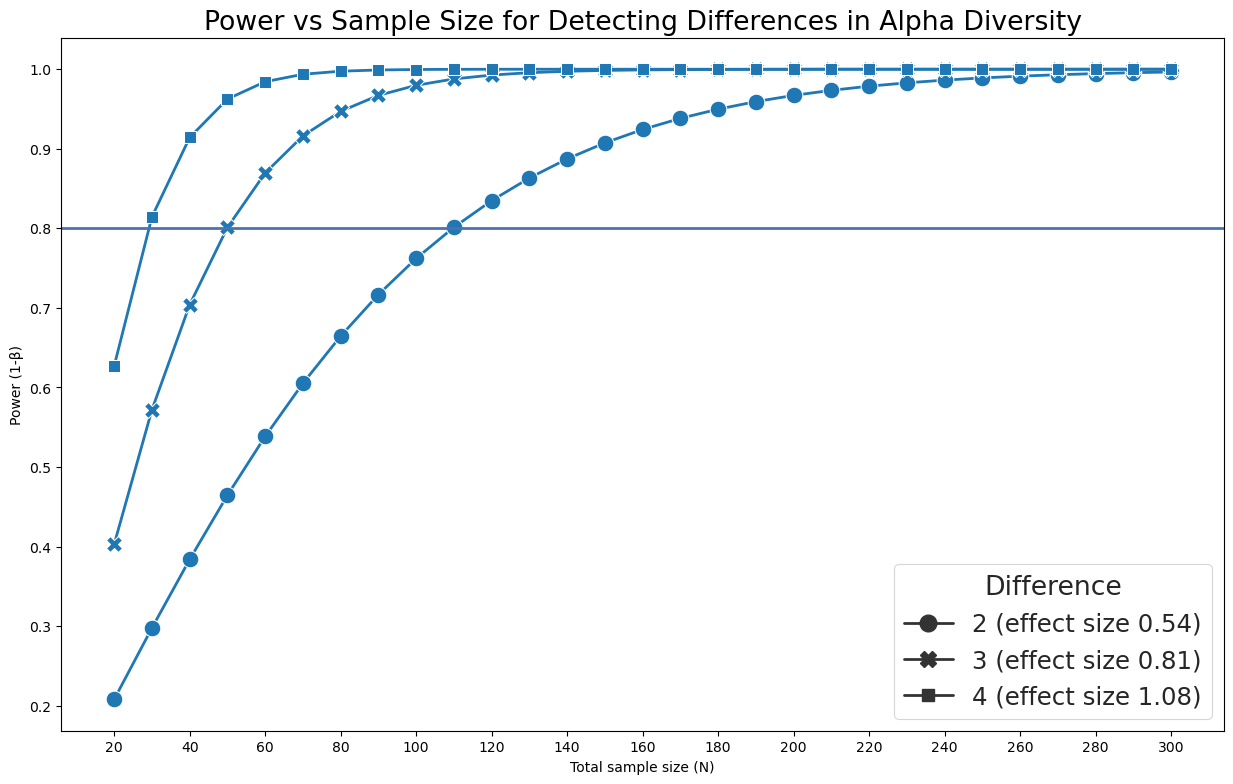

In [66]:
fig, ax1 = plt.subplots(figsize=(15, 9))

sns.set(style="whitegrid")
sns.set_context("paper", font_scale=2, 
                rc={'lines.linewidth': 2, 'lines.markersize': 12})

f = sns.lineplot(x='Total sample size (N)', y='Power (1-β)',
                 markers=True, dashes=False, style='Difference',
                 ax=ax1, data=data_alpha)
ax1.xaxis.set_major_locator(plt.MultipleLocator(20))

plt.axhline(0.8, 0, data_alpha['Total sample size (N)'].max())
plt.title('Power vs Sample Size for Detecting Differences in Alpha Diversity')
fig.savefig('../out/figs/figure1.pdf')

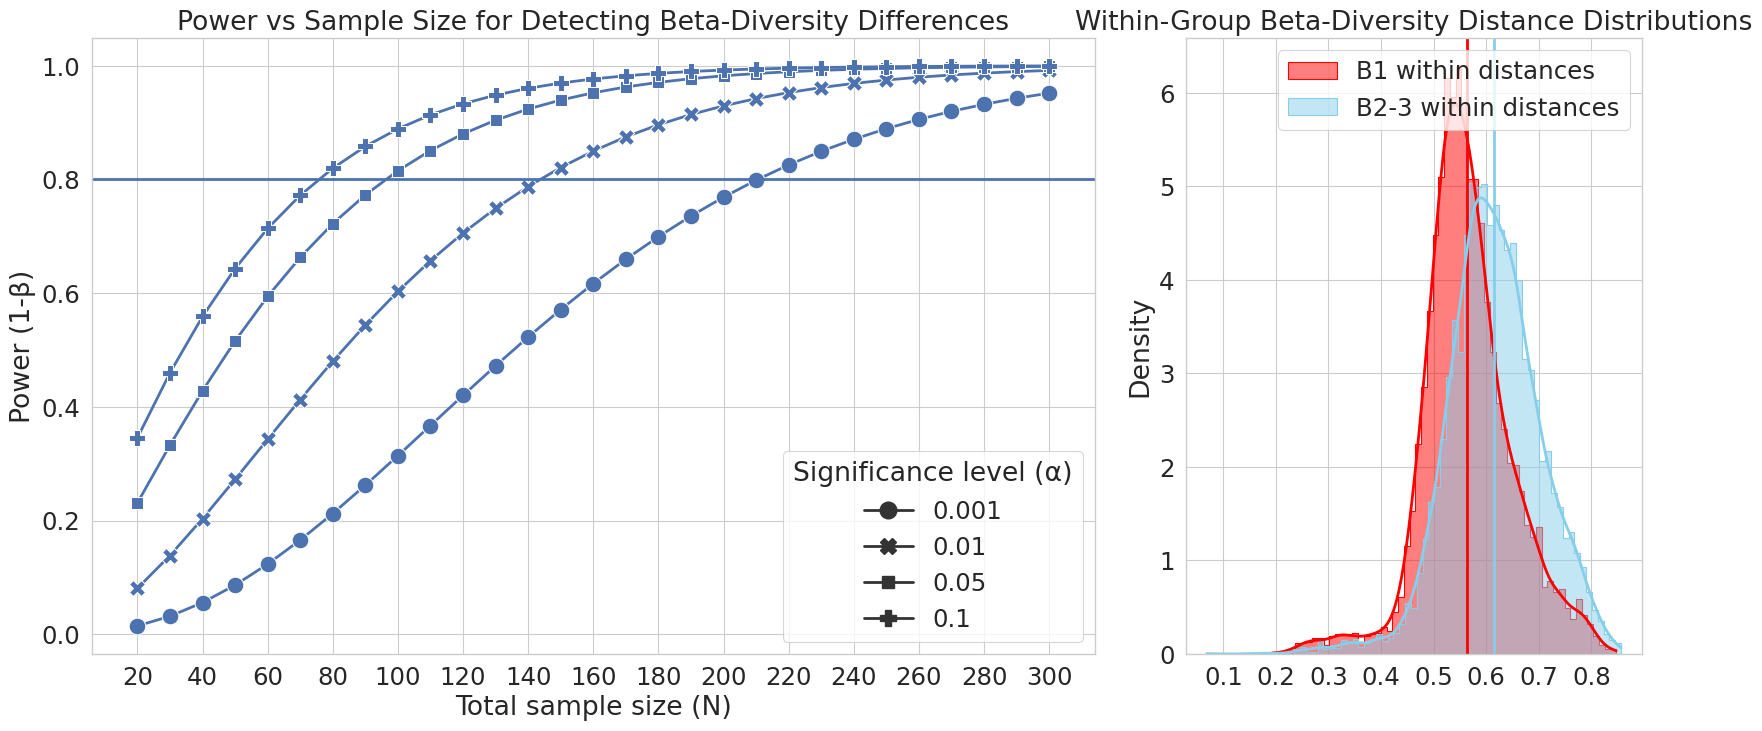

In [68]:
fig = plt.figure(figsize=(20, 8))
grid = plt.GridSpec(ncols=3, nrows=1, hspace=0.2, wspace=0.2)

ax1 = fig.add_subplot(grid[0, :2])
ax2 = fig.add_subplot(grid[0, 2:])

# LEFT: beta power curves (unchanged)
sns.lineplot(x='Total sample size (N)', y='Power (1-β)',
             style='Significance level (α)',
             markers=True, dashes=False,
             ax=ax1, data=data_beta)
ax1.axhline(0.8, 0, data_beta['Total sample size (N)'].max())
ax1.xaxis.set_major_locator(plt.MultipleLocator(20))
ax1.set_title("Power vs Sample Size for Detecting Beta-Diversity Differences")

# RIGHT: distributions using histplot (+ KDE) instead of distplot
sns.histplot(b1_dtx,
             label="B1 within distances",
             color="red",
             kde=True,
             stat="density",
             element="step",
             ax=ax2)

ax2.axvline(mean(b1_dtx), 0, 6, color="red")

sns.histplot(bother_dtx,
             label="B2-3 within distances",
             color="skyblue",
             kde=True,
             stat="density",
             element="step",
             ax=ax2)

ax2.axvline(mean(bother_dtx), 0, 6, color="skyblue")

ax2.xaxis.set_major_locator(plt.MultipleLocator(.1))
ax2.legend()
ax2.set_title("Within-Group Beta-Diversity Distance Distributions")
fig.savefig('../out/figs/figure2.pdf')

## PCoA Visualization

In [69]:
# Perform PCoA on the unweighted UniFrac distance matrix and visualize with Emperor
pcoa_res = diversity.methods.pcoa(distance_matrix=unifrac_res.distance_matrix)

metadata = Metadata.load('../qiita_artifacts/metadata.txt')

viz = emperor.visualizers.plot(
    pcoa=pcoa_res.pcoa,
    metadata=metadata
)

ordination: skbio.OrdinationResults = pcoa_res.pcoa.view(skbio.OrdinationResults)
coords = ordination.samples.copy()
coords.index.name = 'SampleID'

df = coords.join(metadata_df, how='inner')

df = df[df['cd_behavior'] != 'not applicable'].copy()

df['behavior_group'] = df['cd_behavior'].apply(
    lambda x: 'B1' if x == 'Non-stricturing, non-penetrating (B1)' else 'B-other'
)
df['behavior_group'] = pd.Categorical(df['behavior_group'],
                                      categories=['B1', 'B-other'],
                                      ordered=True)

pc1_col = coords.columns[0]
pc2_col = coords.columns[1]

pc1_var = ordination.proportion_explained.iloc[0] * 100
pc2_var = ordination.proportion_explained.iloc[1] * 100

x_lab = f"{pc1_col} ({pc1_var:.1f}% var)"
y_lab = f"{pc2_col} ({pc2_var:.1f}% var)"

fig = px.scatter(
    df,
    x=pc1_col,
    y=pc2_col,
    color='behavior_group',   
    hover_name=df.index,
    hover_data=df.columns,
    title="Unweighted UniFrac PCoA"
)

fig.update_layout(
    xaxis_title=x_lab,
    yaxis_title=y_lab
)

fig.write_html('../out/figs/figure3.html')

/home/mwdai/miniforge3/envs/qiime2-amplicon-2025.7/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.06328221162866764 and the largest is 21.135166388071756.
  warn(


## Random Forest Classification

   N_total  mean_auc   std_auc  n_reps
0       40  0.893287  0.013455      10
1       60  0.897778  0.022915      10
2       80  0.896343  0.010012      10
3      100  0.911296  0.010124      10
4      120  0.918194  0.006033      10


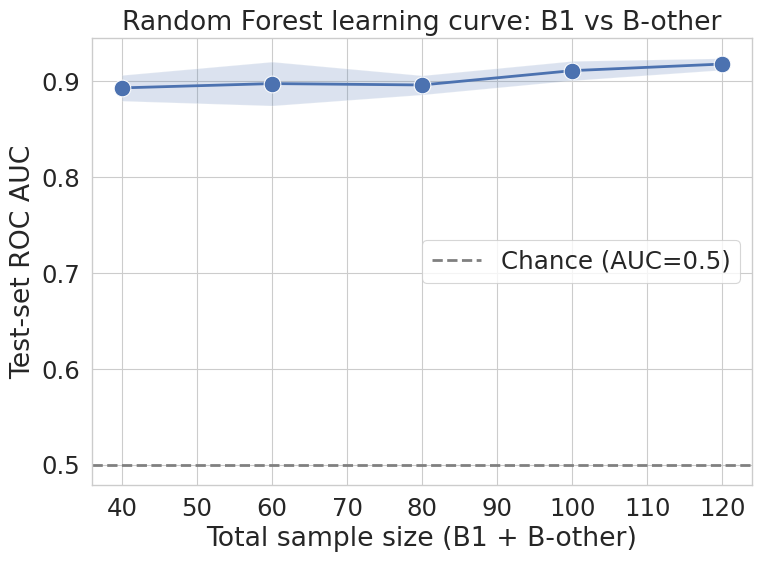

In [70]:
meta_rf = metadata_df.copy()
meta_rf = meta_rf[meta_rf['cd_behavior'] != 'not applicable'].copy()
meta_rf['behavior_group'] = np.where(
    meta_rf['cd_behavior'] == 'Non-stricturing, non-penetrating (B1)',
    'B1',
    'B-other'
)

common_ids = rarefied_df.index.intersection(meta_rf.index)

X_full = rarefied_df.loc[common_ids]
y_full = meta_rf.loc[common_ids, 'behavior_group']

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.3,
    stratify=y_full,
    random_state=42,
)

def rf_learning_curve(X_train,y_train,X_test,y_test,sample_sizes,n_reps=10,random_state=42):
    rng = np.random.default_rng(random_state)

    Xtr = X_train.values
    ytr = y_train.values
    Xte = X_test.values
    yte = y_test.values

    classes = np.unique(ytr)
    if len(classes) != 2:
        raise ValueError(f"Expected 2 classes, got {classes}")

    class_to_idx = {c: np.where(ytr == c)[0] for c in classes}
    min_class_size = min(len(idx) for idx in class_to_idx.values())
    max_balanced_N = 2 * min_class_size

    sample_sizes = [N for N in sample_sizes if N <= max_balanced_N]

    results = []

    yte_bin = (yte == classes[1]).astype(int)

    for N in sample_sizes:
        n_per_class = N // 2
        aucs = []

        for rep in range(n_reps):
            chosen_idxs = []

            for c in classes:
                idxs = class_to_idx[c]
                chosen = rng.choice(idxs, size=n_per_class, replace=False)
                chosen_idxs.append(chosen)

            chosen_idxs = np.concatenate(chosen_idxs)

            X_sub = Xtr[chosen_idxs]
            y_sub = ytr[chosen_idxs]

            clf = RandomForestClassifier(
                n_estimators=500,
                max_depth=None,
                class_weight="balanced",
                n_jobs=-1,
                random_state=random_state + rep,
            )
            clf.fit(X_sub, y_sub)

            y_prob = clf.predict_proba(Xte)[:, 1]
            auc = roc_auc_score(yte_bin, y_prob)
            aucs.append(auc)

        results.append(
            {
                "N_total": N,
                "mean_auc": np.mean(aucs),
                "std_auc": np.std(aucs),
                "n_reps": len(aucs),
            }
        )

    return pd.DataFrame(results)

sample_sizes = list(range(40, X_train.shape[0] * 2, 20))

rf_results = rf_learning_curve(
    X_train,
    y_train,
    X_test,
    y_test,
    sample_sizes,
    n_reps=10,
)

print(rf_results)

plt.figure(figsize=(8, 6))
sns.lineplot(x="N_total", y="mean_auc", data=rf_results, marker="o")
plt.fill_between(
    rf_results["N_total"],
    rf_results["mean_auc"] - rf_results["std_auc"],
    rf_results["mean_auc"] + rf_results["std_auc"],
    alpha=0.2,
)
plt.axhline(0.5, color="gray", linestyle="--", label="Chance (AUC=0.5)")
plt.xlabel("Total sample size (B1 + B-other)")
plt.ylabel("Test-set ROC AUC")
plt.title("Random Forest learning curve: B1 vs B-other")
plt.legend()
plt.tight_layout()
plt.savefig("../out/figs/figure4.pdf")
plt.show()
plt.close()

## Feature Importance

### Gini Importance

In [71]:
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_final.fit(X_train, y_train)

importances = rf_final.feature_importances_

feat_names = X_train.columns 
imp_df = pd.DataFrame({
    'feature': feat_names,
    'gini_importance': importances
})

imp_df = imp_df.sort_values('gini_importance', ascending=False)
imp_df.to_csv('../out/figs/rf_feature_importances.csv', index=False)
imp_df

,feature,gini_importance
21,ACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGC...,0.019425
0,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGC...,0.018845
143,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGC...,0.018790
13,ACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGC...,0.018439
28,ACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGC...,0.015864
...,...,...
1671,ACGTATGGAGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGT...,0.000000
1672,ACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGC...,0.000000
1674,ACGTAGGTGACAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGC...,0.000000
1677,ATGTAGGTGGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGC...,0.000000


### Shap Visualizations

In [72]:
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test)

/home/mwdai/miniforge3/envs/qiime2-amplicon-2025.7/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.



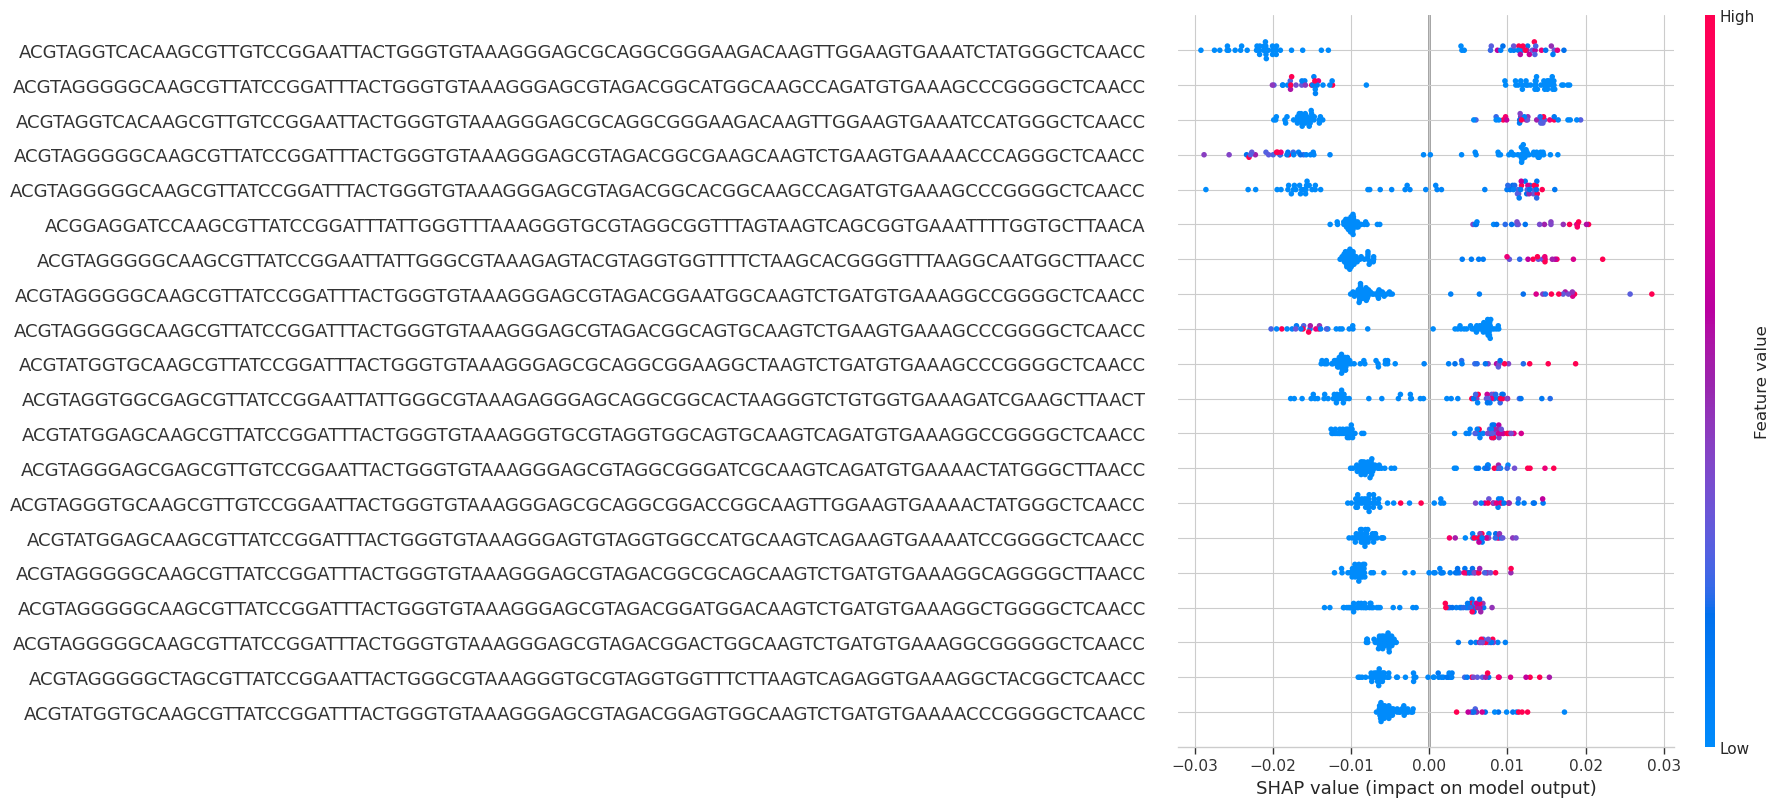

In [78]:
shap.summary_plot(shap_values[:,:,1], X_test, show=False)

plt.savefig("../out/figs/figure5.pdf", dpi=300, bbox_inches='tight')